## <center> Понятие Корреляция. Коэффициент корреляции

In [2]:
import pandas as pd
import statistics

In [3]:
df = pd.read_csv('data/wine_cleared.csv')

>**Корреляция** — статистическая связь двух и более переменных. При изменении значения одной из переменных происходит закономерное изменение другой или других величин. 

Корреляция может быть **положительной** или **отрицательной**; **сильной** или **слабой**. Это показывает, насколько сильно связаны между собой две переменные и каким именно образом

Мерой связи величин, мерой корреляции является **коэффициент корреляции**. Он может принимать значение от -1 до +1.

**Отрицательная корреляция**, коэффициент корреляции < 0 говорит об обратной связи между переменными. При обратной связи увеличение одной из величин ведёт к закономерному уменьшению другой (других) величин. 

**Положительная корреляция**, коэффициент корреляции > 0 говорит о прямой связи между переменными. При прямой связи увеличение одной из величин ведёт к закономерному увеличению другой (других) величин. 

**Коэффициент корреляции = 0** говорит о том, что переменные независимы друг от друга, по крайней мере линейно, но это вовсе не значит, что между ними нет какой-то более сложной взаимосвязи. Это достаточно редкое явление, которое может встретиться на конкретном наборе данных.

>Понимание корреляции приводит нас к понятию **мультиколлинеарности** — такой сильной зависимости переменных друг от друга, что она затрудняет анализ и оценку будущей модели машинного обучения. 

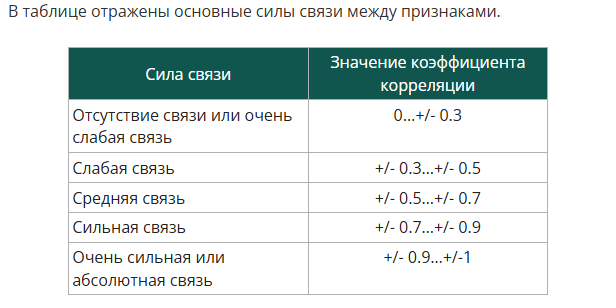

>Принято считать, что при коэффициенте корреляции +/-0,7 связь между признаками сильная и приводит к мультиколлинеарности.

Для расчёта коэффициента корреляции применим функцию [df.corr()](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.corr.html) библиотеки pandas.
```python
data.corr()

In [ ]:
correlation = df['price'].corr(df['points'])

In [11]:
print(f"Величина коэффициента корреляции между ценой за бутылку и баллами за вино - {round(correlation,6)}")

Величина коэффициента корреляции между ценой за бутылку и баллами за вино - 0.402137


Результатом функции df.corr() является матрица корреляции. 

>**Матрица корреляции** — таблица, заголовками и строками которой являются названия признаков в датасете. На пересечении строк и столбцов находится значение коэффициента корреляции этих двух признаков.

Данная матрица имеет значение 1 по главной диагонали, так как единица означает корреляцию признака с самим собой. Матрица является **симметричной**. 

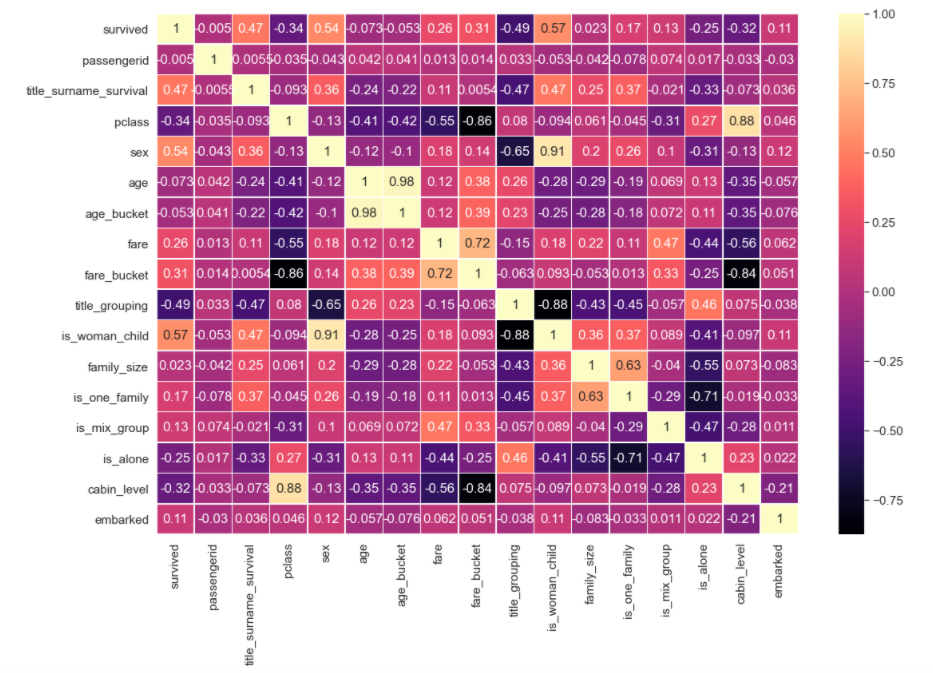

---

## <center> Ковариация

**Ковариация** - показатель совместного изменения двух переменных, вычисляемая как сумма произведений от средних для каджой пары значений x и y:

$$Cov(X,Y) = \frac{\sum_{i=1}^{n} (x_i- \bar{X}) \cdot (y_i - \bar{Y})}{n} = \sigma_{xy}$$

Указывает на направление корреляции между двумя переменными. Если одна переменная увеличивается, а вторая уменьшается - ковариация отрицательная. Если направление изменения одинаковое - коэффициент ковариации положительный

## <center> Типы корреляций. 

Аргумент ```method``` метода ```df.corr()``` указывает на название используемого метода расчёта корреляции: 
* 'pearson' — корреляция Пирсона, 
* 'kendall' — корреляция Кендалла, 
* 'spearman' — корреляция Спирмена. 

Каждый метод может быть применён для разных типов данных. Давайте разберёмся, чем отличаются эти методы и для каких типов данных применять каждый из них.

## <center>  Линейный коэффициент корреляция Пирсона

>**Корреляция Пирсона** - это стандартизованная ковариация (деленная на стандартные отклонения)

>**Коэффициент корреляции Пирсона** используется для вычисления линейной взаимосвязи между признаками.

```python
correlation = df['price'].corr(df['points'])
# Рассчет коэффициента коррелиции методом Пирсона
```

Коэффициент корреляции рассчитывается по формуле: 

$$r_{xy} = \frac{ \sum_{i=1}^{n} (x_i - \bar{X}) \cdot (y_i - \bar{Y})}{\sqrt{ \sum_{i=1}^{n} (x_i - \bar{X})^2} \cdot \sqrt{ \sum_{i=1}^{n} (y_i - \bar{Y})^2}} = \frac {Cov(X,Y)}{\sigma_x \cdot \sigma_y} = \frac{\sigma_{xy}}{\sigma_{x} \cdot \sigma_{y}}$$

Линейная взаимосвязь — вид связи между признаками, в котором изменение одного признака  всегда приводит к изменению другого признака  на величину, пропорциональную изменению , в соответствии с правилом:  (уравнение прямой), где  и  — некоторые коэффициенты.

Коэффициент Пирсона **чувствителен к выбросам**

#### <center> Hормальное распределение 

>Если признак является совокупностью очень редких событий, например аварии на дорогах, то распределение признака нормальным не будет.

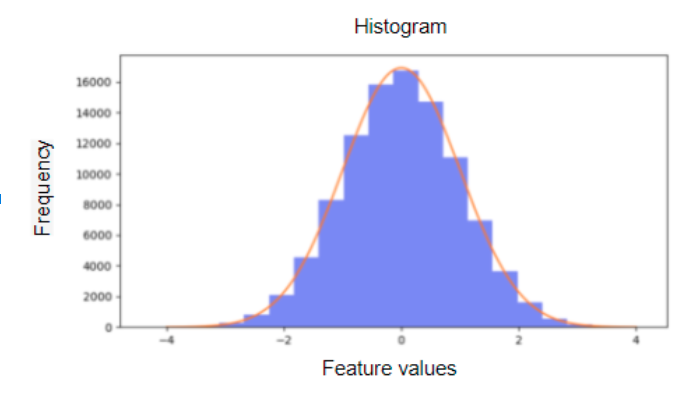
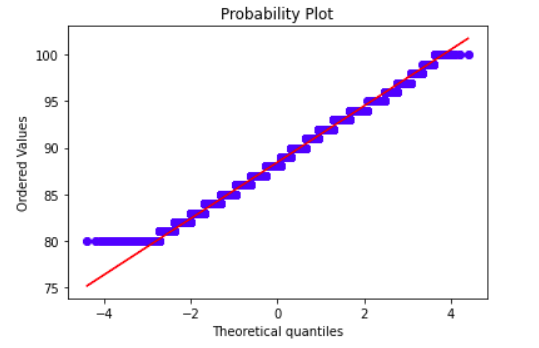

На гистограмме распределение должно напоминать колокол (левый график на рисунке), а q-q plot должен напоминать прямую линию (правый график на рисунке).

>Давайте проверим наши данные винных обзоров на нормальность, используя метод визуализации.

Для этого воспользуемся пакетом [stats](https://docs.scipy.org/doc/scipy/reference/stats.html#module-scipy.stats) статистических распределений и функций, а также знакомой нам библиотекой matplotlib для построения графиков.

Код для построения графиков:

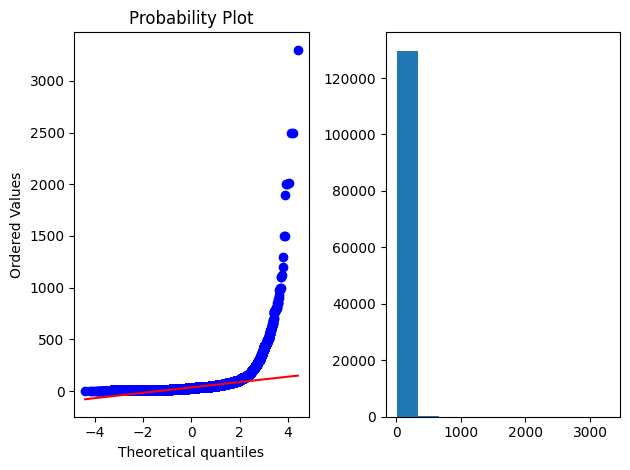

In [6]:
import matplotlib.pyplot as plt # библиотека визуализации
from scipy import stats # библиотека для расчетов

plt.subplot(1, 2, 1) # задаем сетку рисунка количество строк и столбцов
stats.probplot(df['price'], plot=plt) # qq plot

plt.subplot(1, 2, 2) # располагаем второй рисунок рядом
plt.hist(df['price']) # гистограмма распределения признака

plt.tight_layout() # чтобы графики не наезжали другу на друга, используем tight_layout

plt.show() # просмотр графика

Кажется, признак распределён ненормально, так как q-q plot имеет изогнутую линию, а гистограмма распределения совершенно не похожа на колокол.

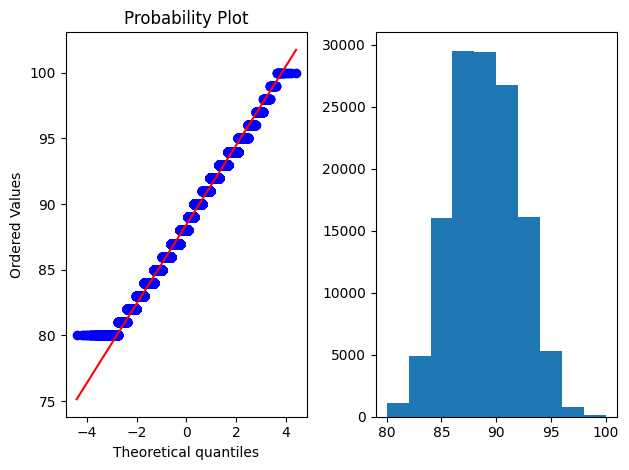

In [7]:
import matplotlib.pyplot as plt # библиотека визуализации
from scipy import stats # библиотека для расчетов

plt.subplot(1, 2, 1) # задаем сетку рисунка количество строк и столбцов
stats.probplot(df['points'], plot=plt) # qq plot

plt.subplot(1, 2, 2) # располагаем второй рисунок рядом
plt.hist(df['points']) # гистограмма распределения признака

plt.tight_layout() # чтобы графики не наезжали другу на друга, используем tight_layout

plt.show() # просмотр графика

* Корреляция между непрерывными признаками, которые имеют близкое к нормальному распределение, может быть рассчитана с использованием стандартной корреляции Пирсона. 
* Для категориальных данных используются методы ранговой корреляции, например Спирмена и Кендалла, которые будут изучены в следующем юните. 
* Для непрерывных переменных, имеющих большое количество выбросов или распределённых ненормально, могут использоваться методы по устранению выбросов и нормализации данных, которые будут изучены далее в курсе. Также могут быть использованы методы ранговой корреляции.

## <center> Ранговый коэффициент корреляции Спирмана

>**Ранговая корреляция**— это вид корреляции, отражающий отношения переменных, упорядоченных по возрастанию их значения. 
* **Ранги** — это порядковые номера единиц совокупности в упорядоченном (ранжированном) ряду. Если проранжировать совокупность по двум признакам, связь между которыми изучается, то полное совпадение рангов означает максимально тесную **прямую** связь, а полная противоположность рангов — максимально тесную **обратную** связь.

>**Коэффициент корреляции Спирмена** используется для вычисления взаимосвязей между категориальными переменными.

$$ r_s = 1 - \frac{6 \cdot \sum d^2}{n \cdot (n^2 -1)}$$

Чтобы рассчитать коэффициент корреляции Спирмена, вам необходимо передать в ```df.corr()``` аргумент ```method = 'spearman' ```.

In [17]:
correlation = df['price'].corr(df['points'],method = 'spearman')
print(f'Коэффициент корреляции Спирмена для признаков point и price - {round(correlation,2)}')

Коэффициент корреляции Спирмена для признаков point и price - 0.58


Иногда мы можем применить ранговую корреляцию и для числовых переменных, которые распределены ненормально или если между ними существует нелинейная связь. 
>Лучшим вариантом будет придерживаться правил корреляций каждого из методов: **для непрерывных нормально распределённых используем корреляцию Пирсона, для категориальных — ранговую**. Однако в спорных случаях мы рассматриваем несколько вариантов корреляций. 

Для ранговой корреляции существует ещё один метод расчёта — **корреляция Кендалла**.

## <center> Корреляция Кендалла

Так же, как и корреляция Спирмена, корреляция Кендала предусмотрена для нахождения взаимосвязей между категориальными переменными. Для расчёта коэффициента корреляции Кендалла необходимо передать в изученный нами метод ```df.corr()``` аргумент ```method = 'kendall'```. 

In [18]:
correlation = df['price'].corr(df['points'],method = 'kendall')
print(f'Коэффициент корреляции Спирмена для признаков point и price - {round(correlation,2)}')

Коэффициент корреляции Спирмена для признаков point и price - 0.43


## <center> Корреляция Мэтьюса

Бинарные признаки являются подгруппой категориальных. Мы по-прежнему можем использовать методы ранговых корреляций для расчёта связи между переменными. 

>Кроме этого, существует **корреляция Мэтьюса** — мера силы связи между бинарными переменными.

В df.corr() нет расчёта для корреляции Мэтьюса, но мы можем воспользоваться библиотекой ```scikit-learn``` и её функцией [matthews_corrcoef()](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.matthews_corrcoef.html#sklearn.metrics.matthews_corrcoef) для расчёта коэффициента корреляции Мэтьюса.

>*scikit-learn* — это библиотека с реализацией готовых алгоритмов для машинного обучения. Более подробно вы познакомитесь с ней в модулях, посвящённых машинному обучению.

Для начала установим библиотеку scikit-learn.
```python
pip install scikit-learn

Затем импортируем нужную нам функцию для дальнейшей работы.

from sklearn.metrics import matthews_corrcoef

В нашем датасете винных обзоров нет бинарных переменных, но мы можем воспользоваться учебным примером.

In [20]:
from sklearn.metrics import matthews_corrcoef

x = [+1, -1, +1, +1] # список значений признака х
y = [+1, +1, +1, -1] # список значений признака y

round(matthews_corrcoef(x, y),2) # рассчитаем коэффициент корреляции Мэтьюса

-0.33

>Коэффициент корреляции Мэтьюса может быть полезен в случае, когда в датасете представлены только бинарные переменные. Кроме того, этот коэффициент используется для оценки качества моделей, ответы которых также бинарны. 

---

## <center> Визуализация корреляций. 


In [1]:
import pandas as pd
data = pd.read_csv('data/model.csv')

In [2]:
data.head()

,Month,Year,Waist,Hips,Height,Weight,BMI,Waist/Hip
0,December,1953,24.000000,36.000000,65.000000,118.000000,19.630000,0.670000
1,January,1954,23.433172,34.698708,66.057258,114.936066,18.232168,0.677916
2,February,1954,23.433172,34.698708,66.057258,114.936066,18.232168,0.677916
3,March,1954,24.000000,35.000000,66.000000,118.000000,19.040000,0.690000
4,April,1954,23.433172,34.698708,66.057258,114.936066,18.232168,0.677916


* BMI — индекс массы тела (ИМТ)
* year — год размещения модели в журнале
* month — месяц размещения
* waist — обхват талии модели
* hips — обхват бёдер модели
* height — рост модели
* weight — вес модели
* waist/hip — соотношение обхвата талии и бёдер

### <center> Матрица корреляций

В случае большого количества данных в датасете матрица, возвращаемая методом pandas [data.corr()](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.corr.html), становится нечитаемой.

>Постройте матрицу корреляций для датасета. В ответ впишите самый высокий коэффициент корреляции. Ответ округлите до сотых.

In [3]:
corr_matrix = data.corr(numeric_only = True)
display(corr_matrix)

,Year,Waist,Hips,Height,Weight,BMI,Waist/Hip
Year,1.000000,0.292518,-0.281576,0.284482,-0.010753,0.025309,0.458945
Waist,0.292518,1.000000,0.283060,0.372637,0.452704,0.136549,0.742284
Hips,-0.281576,0.283060,1.000000,0.228054,0.541836,0.211395,-0.422412
Height,0.284482,0.372637,0.228054,1.000000,0.706569,-0.037934,0.198754
Weight,-0.010753,0.452704,0.541836,0.706569,1.000000,0.212701,0.067543
BMI,0.025309,0.136549,0.211395,-0.037934,0.212701,1.000000,-0.010173
Waist/Hip,0.458945,0.742284,-0.422412,0.198754,0.067543,-0.010173,1.000000


In [12]:
largest_list = []
for columns in corr_matrix:
    second_highest_value = corr_matrix[columns].nlargest(2).iloc[-1]
    largest_list.append(second_highest_value)
print(f'Самый высокий коэффициент корреляции - {round(max(largest_list),2)}')

Самый высокий коэффициент корреляции - 0.74


Cпециалисты по данным отдают предпочтение методам визуализации. Один из таких — **тепловая матрица корреляций**.

### <center>Тепловая матрица корреляций

Импортируем библиотеку для дальнейшего использования:
```python
import seaborn as sns

Для построения тепловой матрицы корреляций мы воспользуемся методом [sns.heatmap()](https://seaborn.pydata.org/generated/seaborn.heatmap.html) библиотеки seaborn

Метод принимает на вход двумерный массив данных под аргументом ```data```. Это может быть матрица корреляций, полученная методом ``df.corr()```, матрица пропущенных значений, полученная методом ```df.isnull()```, набор данных и многое другое. 

Передадим в метод ```heatmap()``` нашу матрицу корреляций ```corr()``` (параметр numeric_only=True игнорирует нечисловые значения):

<Axes: >

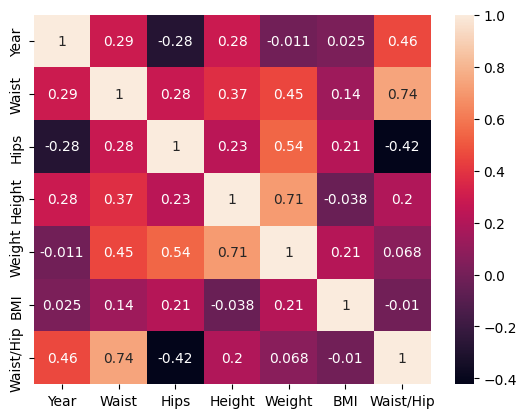

In [14]:
import seaborn as sns
sns.heatmap(data.corr(numeric_only=True), annot=True)

На горизонтальной и вертикальной осях располагаются названия признаков нашего датасета. По главной диагонали — единицы. Матрица симметрична. Справа от матрицы располагается тепловая шкала коэффициентов корреляции: от минимума -0.42 (это корреляция между признаками waist/hip + hips) и максимума по шкале — 1. 

Такую тепловую матрицу очень удобно интерпретировать: в тёплых светлых оттенках отражена положительная корреляция между признаками, в тёмных холодных — отрицательная корреляция. Например, самая большая отрицательная взаимосвязь составляет -0.42, а самая большая положительная — 0.74.

С помощью такой матрицы очень удобно оценивать мультиколлинеарность в данных, делать выводы о связях между признаками.

Например, в нашем наборе данных мультиколлинеарность практически отсутствует, так как из материала прошлого модуля мы знаем, что она возникает из-за признаков с сильной и очень сильной корреляцией. По шкале корреляций это от 0.7 и выше; у нас есть такие признаки с корреляцией выше 0.7 (например: waist/hip + waist). Коэффициент корреляции лишь немного выше, поэтому такой признак, скорее всего, не будет удалён из набора данных. 

Также у метода heatmap имеется много аргументов, которые позволяют настроить цветовую гамму графика, управлять его элементами и отображением. Подробнее об этом вы прочтёте здесь: [Seaborn Heatmaps: 13 способов настроить визуализацию матрицы корреляции](https://datastart.ru/blog/read/seaborn-heatmaps-13-sposobov-nastroit-vizualizaciyu-matricy-korrelyacii)

## <center>Scatterplot

Иногда нам необходимо рассмотреть связь между признаками как распределение. Матрица корреляции может показать нам только силу связи и её направление (плюс/минус). Чтобы рассмотреть распределение и характер связи, существует **точечная диаграмма рассеивания**.

>**Точечная диаграмма рассеивания** — это такая диаграмма, в которой каждое значение, которое принимает признак в датасете, отражено точкой.

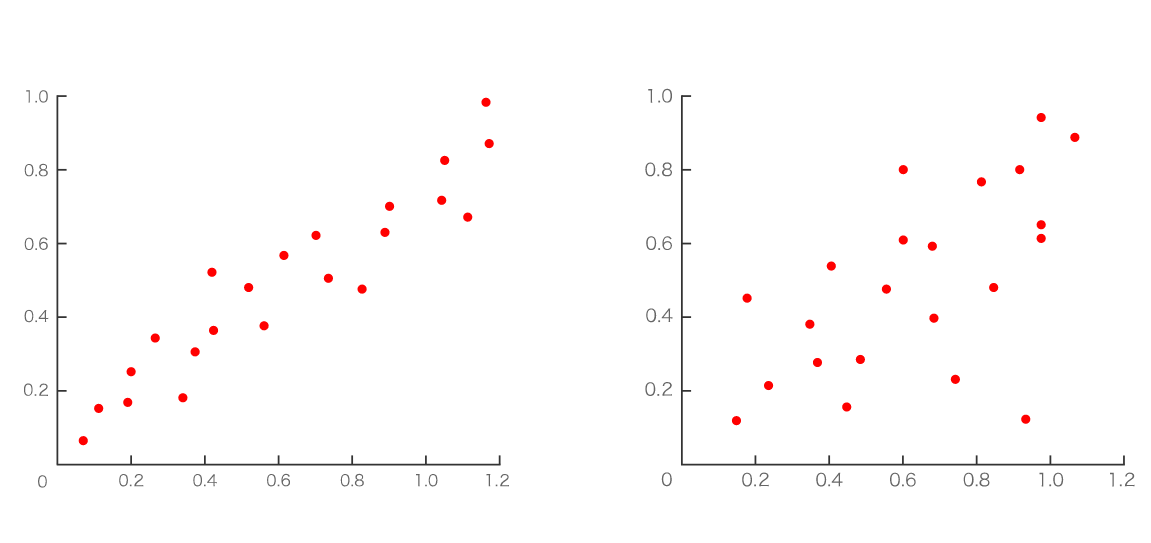

Подобная диаграмма помогает установить характер и силу связи признаков. Присвоив каждой оси переменную, мы можем определить наличие связи между переменными. Сила связи (коэффициент корреляции) зависит от того, насколько плотно расположены точки на диаграмме. Например, на рисунке слева точки расположены более плотно, чем справа. Это означает большую силу связи. 

Метод, который мы будем использовать, — [sns.scatterplot()](https://seaborn.pydata.org/generated/seaborn.scatterplot.html). Он отражает связь между переменными, где есть аргументы метода x, y, и признаки, которые мы хотим исследовать.

Возьмём для примера две пары признаков:
* по оси x="Waist/Hip" — соотношение обхвата талии/бедер, по оси y="Waist" — обхват талии;
* по оси x="Weight" — вес модели, а по оси y="Year" — год размещения модели в журнале.

Построим для них точечную диаграмму:

<Axes: xlabel='Waist/Hip', ylabel='Waist'>

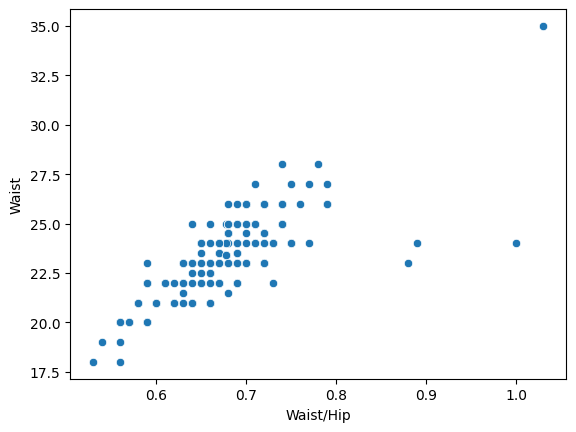

In [15]:
sns.scatterplot(data=data, x="Waist/Hip", y="Waist")

>Построим диаграмму для следующей пары признаков и сравним их.

<Axes: xlabel='Weight', ylabel='Year'>

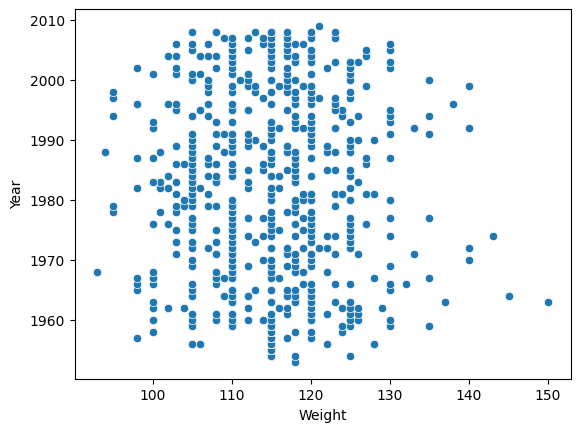

In [16]:
sns.scatterplot(data=data, x="Weight", y="Year")

Умение интерпретировать графики очень важно для дата-сайентиста и сокращает время работы над разведывательным анализом данных. Опытным специалистам по данным требуется несколько секунд, чтобы определить характер связи: линейная/нелинейная, прямая/обратная, — а также силу связи, или коэффициент корреляции. 

Чтобы делать это так же быстро, необходимо помнить несколько правил. Давайте повторим их и закрепим эти знания визуализацией. 

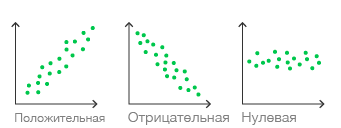

* При положительной корреляции увеличение одного признака приводит к увеличению другого. И наоборот.
* При отрицательной связи увеличение одного из признаков приводит к уменьшению другого и наоборот.
* При нулевой корреляции признаки распределяются независимо друг от друга, что видно на рисунке.

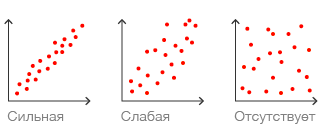

* При сильной связи точки на графике расположены близко друг к другу. 
* Чем связь слабее, тем дальше находятся точки друг от друга. 

На графике изображена сильная связь с коэффициентом корреляции ~0.95, слабая с коэффициентом корреляции ~0.5 и нулевая корреляция.

**Диаграмма рассеивания в данных**— удобный инструмент анализа, но, к сожалению, только для пары признаков. **Тепловая матрица корреляций** удобна для анализа всего датасета, но показывает только силу и направления корреляции (плюс/минус), а информации о распределении признаков мы не получаем. 

## <center> График попарных отношений PairPlot

Давайте построим [график PairPlot](https://seaborn.pydata.org/generated/seaborn.pairplot.html) для нашего набора данных:

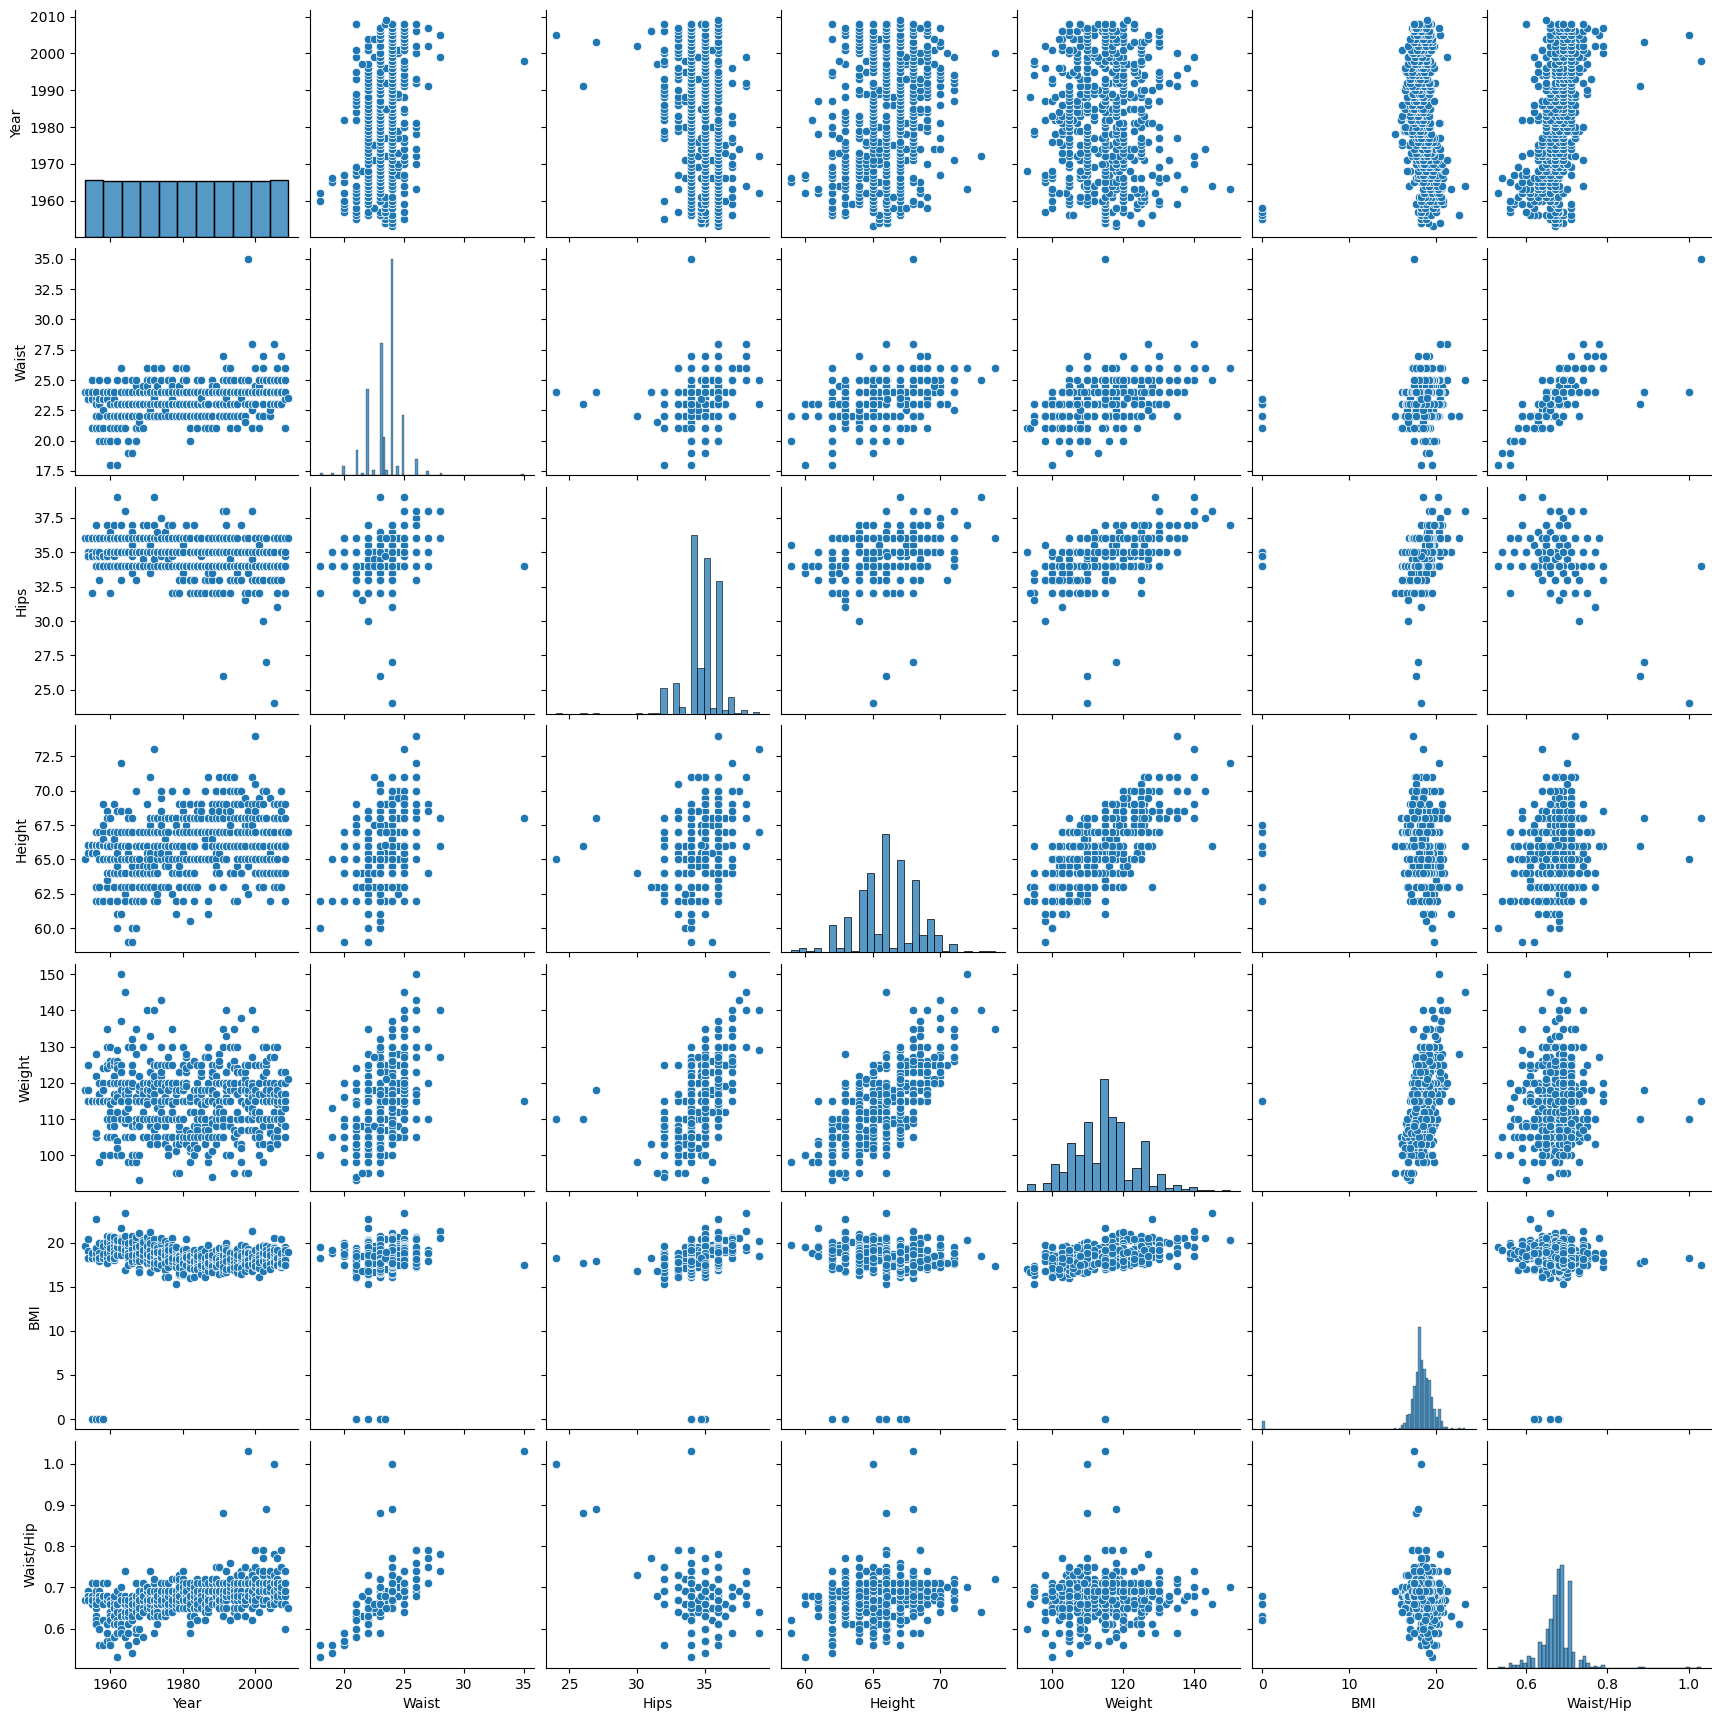

In [17]:
sns.pairplot(data)

Структура похожа на изученную нами тепловую матрицу корреляций. На осях х и у расположились признаки из набора данных. На главной диагонали вместо единиц представлены графики-распределения конкретной величины. В остальных ячейках мы можем увидеть точечный график связей признаков между собой — это scatterplot, который мы строили для пары признаков. Здесь это пара признаков, которые пересекаются между собой.

>Посчитайте коэффициент корреляции между признаками Weight (вес модели) и Height (рост модели). Ответ округлите до сотых.

In [19]:
correlation = data['Weight'].corr(data['Height'])
print(f'Коэффициент корреляции между признаками Вес и Рост составляет - {round(correlation,2)}')

Коэффициент корреляции между признаками Вес и Рост составляет - 0.71


---

In [21]:
import statistics
print(f"Среднее значение weight составляет {round(statistics.mean(data['Weight']),2)}")

Среднее значение weight составляет 114.94


In [22]:
print(f"Среднее значение height составляет {round(statistics.mean(data['Height']),2)}")

Среднее значение height составляет 66.06
